# Tests — simulation methods

Justification for the simulator chosen in the clean pipeline [spatial_analysis_article.ipynb](spatial_analysis_article.ipynb). The model can be simulated two ways, differing only in how the latent Gaussian field $\mathbf{Y}_n\sim\mathcal{N}(\mathbf0,\boldsymbol\Sigma)$ is drawn:

- **Cholesky** — `simulate_cholesky`: factor $\boldsymbol\Sigma=\mathbf L\mathbf L^\top$ once, then $\mathbf Y=\mathbf L\mathbf V$, with a burn-in. **This is what the pipeline uses.**
- **scipy/SVD** — `simulate_history` / `step_spatial_markov`: `rng.multivariate_normal` (SVD factorisation), refactored every step, no burn-in.

This notebook is the **only** place the scipy/SVD *generation* is exercised. We show the two simulators sample the same law (matching marginals and $\hat\sigma$ recovery), then look at whether the burn-in matters.


## Setup

Rebuild `dict_model_params` exactly as in the pipeline notebook (imports, single-site fit outputs, station subset, exit-probability closures).

In [1]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from article_code.util_files import config
from spatial_bmcd.archive_old_single_latent_field.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    run_simulation_mle_experiment,
    load_all_station_rr,
    build_joint_df_occurrence_from_raw_data,
    history_from_Rbin_drop_ambiguous_spell_after_nan,
    split_history_by_year,
    mle_sigma_pairwise,
    mle_sigma_pairwise_histories,
    simulate_cholesky,
)
from spatial_bmcd.archive_old_single_latent_field.spatial_plotting import (
    plot_stations_geomap,
    plot_stations_map,
    plot_tail_probability_illustration,
    plot_gaussian_field_with_thresholds,
)

In [2]:
# Load single-site outputs produced by notebook 01.
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)

stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

print(f"{len(spells)} stations in spells JSON; {len(stations_used)} in metadata; "
      f"{df_fit_dry['city'].nunique()} cities in dry fit, "
      f"{df_fit_wet['city'].nunique()} in wet fit")

209 stations in spells JSON; 209 in metadata; 209 cities in dry fit, 209 in wet fit


In [3]:
COUNTRIES = ["PT", "ES"]
SEASON = "spring"

df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
    df_fit_dry, df_fit_wet, stations_used,
    countries=COUNTRIES, season=SEASON,
)
print(f"{len(df_fit_dry_sub)} stations kept for season={SEASON}, countries={COUNTRIES}")

plot_stations_geomap(df_fit_dry_sub).show()
# plot_stations_map(df_fit_dry_sub, color_col="xi");

35 stations kept for season=spring, countries=['PT', 'ES']


In [4]:
dict_model_params = build_dict_model_params(
    df_fit_dry_sub, df_fit_wet_sub, spells, season=SEASON,
)
print(f"Built model parameters for {len(dict_model_params)} stations")

# Sanity check: q^(0)(1), q^(0)(5), q^(1)(1) for the first station
city0 = next(iter(dict_model_params))
p = dict_model_params[city0]
print(f"{city0}: q_dry(1)={p['q_d_dry_function'](1):.3f}, "
      f"q_dry(5)={p['q_d_dry_function'](5):.3f}, "
      f"q_dry(20)={p['q_d_dry_function'](20):.3f}, --- "
      f"q_wet(1)={p['q_d_wet_function'](1):.3f}",
      f"q_wet(5)={p['q_d_wet_function'](5):.3f}",
      f"q_wet(20)={p['q_d_wet_function'](20):.3f}")

  0%|          | 0/35 [00:00<?, ?it/s]

 46%|████▌     | 16/35 [00:00<00:00, 156.92it/s]

100%|██████████| 35/35 [00:00<00:00, 194.09it/s]

Built model parameters for 35 stations
ALACANT/ALICANTE: q_dry(1)=0.142, q_dry(5)=0.101, q_dry(20)=0.074, --- q_wet(1)=0.538 q_wet(5)=0.521 q_wet(20)=0.441


### Same check through `run_simulation_mle_experiment` — and the two simulators

The cell above fed `mle_sigma_pairwise` a history from `simulate_cholesky`. We now repeat the classic-vs-`approx_cdf` comparison through `run_simulation_mle_experiment`, which generates its histories with a **different simulator**, `simulate_history` / `step_spatial_markov`. This is a good moment to state precisely how the two simulators relate.

**They sample from the same model.** Both implement exactly the latent-field construction of the article: a centred Gaussian field $\mathbf{Y}_n\sim\mathcal{N}(\mathbf 0,\boldsymbol\Sigma_\theta)$ with the exponential correlation of [main.tex Eq. (16)](../Spatialisation-Rain-Occurrence-Generator-article/main.tex#L264), then the **identical** sign-flip + threshold update rule [Eq. (3)](../Spatialisation-Rain-Occurrence-Generator-article/main.tex#L91) $Z_n(\mathbf s)=(-1)^{R_n(\mathbf s)}Y_n(\mathbf s)\le z_{\mathbf s}(R_n,D_n)$. The *only* substantive difference is **how the Gaussian vector $\mathbf{Y}_n$ is drawn**:

| | `step_spatial_markov` (→ `simulate_history` → `run_simulation_mle_experiment`) | `simulate_cholesky` |
|---|---|---|
| Gaussian draw | `rng.multivariate_normal(0, C)` **every step** | factor $\boldsymbol\Sigma=\mathbf L\mathbf L^\top$ **once** (Cholesky), then $\mathbf Y_n=\mathbf L\mathbf V_n$, $\mathbf V_n\sim\mathcal N(\mathbf 0,\mathbf I)$ |
| Factorization | SVD (NumPy's default), re-done per call | Cholesky, computed a single time |
| Init / burn-in | caller-set ($R_0{=}D_0{=}1$), **no burn-in** | deterministic all-dry $R_0{=}0,D_0{=}1$, then discard $T_\text{burn}$ days |
| Returns | many independent runs + their MLEs | one trajectory |

**Why this makes no statistical difference.** Drawing $\mathbf Y=\mathbf A\mathbf V$ with $\mathbf V\sim\mathcal N(\mathbf 0,\mathbf I)$ yields $\operatorname{Cov}(\mathbf Y)=\mathbf A\mathbf A^\top$, so **any** factor with $\mathbf A\mathbf A^\top=\boldsymbol\Sigma$ produces the same law $\mathcal N(\mathbf 0,\boldsymbol\Sigma)$. Cholesky ($\mathbf L$) and the SVD factor used inside `multivariate_normal` are two such factors; this is exactly the Cholesky-sampling argument of [main.tex §5, step 1](../Spatialisation-Rain-Occurrence-Generator-article/main.tex#L276) (Gentle, 2009, §7.4). Hence both simulators draw from the *identical* distribution and the estimator behaves the same way — only the realized sample paths differ for a given seed (a different deterministic transform of the underlying normals).

**Where they do differ, and why it is practical not theoretical.** (i) Cholesky factorizes once — $O(J^3)$ up front, then $O(J^2)$ per step — whereas `multivariate_normal` refactorizes on every call; (ii) NumPy's default SVD is more robust when $\boldsymbol\Sigma$ is near-singular (large $\sigma$, or near-coincident stations), while Cholesky needs strict positive-definiteness — the article's optional jitter $\varepsilon\mathbf I$ ([commented in §5, step 1](../Spatialisation-Rain-Occurrence-Generator-article/main.tex#L278)) addresses that; (iii) only `simulate_cholesky` applies the burn-in that the article recommends, so it is the right tool for drawing *from a fitted model*, whereas `simulate_history` is the lightweight engine for the simulate-and-refit sanity checks.

## Cholesky vs scipy/SVD — same law

Simulate one long history at a fixed $\sigma$ with each method and compare per-station wet-day frequencies and the recovered $\hat\sigma$. They should agree up to Monte-Carlo noise.

max |wet_chol - wet_svd|       = 0.0252
sigma_true = 0.2
  Cholesky  simulator -> sigma_hat = 0.1991
  scipy/SVD simulator -> sigma_hat = 0.2035


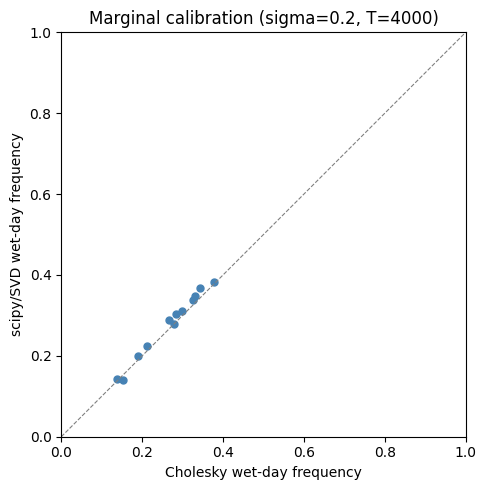

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from spatial_bmcd.archive_old_single_latent_field.spatial_model import simulate_history, build_C_from_sigma

SIGMA = 0.2
cmp_params = {c: dict_model_params[c] for c in sorted(dict_model_params)[:12]}
names = sorted(cmp_params)
T = 4000

# Cholesky simulator (the pipeline's method), with burn-in.
h_chol = simulate_cholesky(
    sigma=SIGMA, params_by_station=cmp_params, n_steps=T, n_burn=500, seed=0)

# scipy/SVD simulator (numpy multivariate_normal), no burn-in.
C = build_C_from_sigma(names, cmp_params, sigma=SIGMA)
R0 = np.zeros(len(names), dtype=int)
D0 = np.ones(len(names), dtype=int)
h_svd = simulate_history(
    n_steps=T, R0=R0, D0=D0, C=C,
    params_by_station=cmp_params, station_names=names, seed=0)

wet_chol = h_chol["R"][1:].mean(axis=0)
wet_svd = h_svd["R"][1:].mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.8)
ax.scatter(wet_chol, wet_svd, s=25, color="steelblue")
ax.set_xlabel("Cholesky wet-day frequency")
ax.set_ylabel("scipy/SVD wet-day frequency")
ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f"Marginal calibration (sigma={SIGMA}, T={T})")
plt.tight_layout()

r_chol = mle_sigma_pairwise(h_chol, cmp_params, bounds=(1e-3, 2.0), vectorized=True)
r_svd = mle_sigma_pairwise(h_svd, cmp_params, bounds=(1e-3, 2.0), vectorized=True)
print(f"max |wet_chol - wet_svd|       = {np.abs(wet_chol - wet_svd).max():.4f}")
print(f"sigma_true = {SIGMA}")
print(f"  Cholesky  simulator -> sigma_hat = {r_chol['sigma_hat']:.4f}")
print(f"  scipy/SVD simulator -> sigma_hat = {r_svd['sigma_hat']:.4f}")


## Effect of the burn-in

Start `simulate_cholesky` from the deterministic all-dry state with `n_burn=0` and track the cross-station wet fraction day by day. If a burn-in is needed, the first days sit away from the stationary level and drift toward it; the running mean shows how many days that takes and motivates the default `n_burn` used in the pipeline.

wet fraction: days 1-50 = 0.358, days 500+ = 0.263


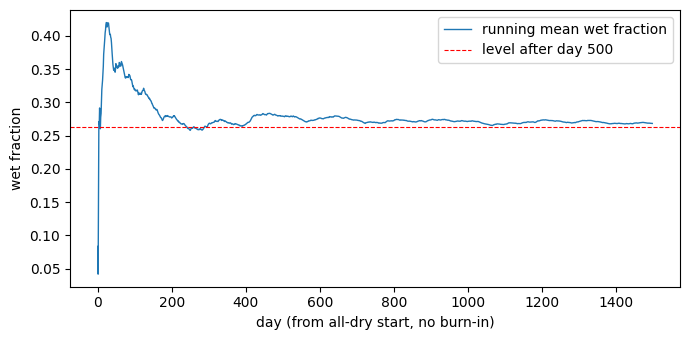

In [6]:
h0 = simulate_cholesky(
    sigma=SIGMA, params_by_station=cmp_params, n_steps=1500, n_burn=0, seed=1)

wet_frac_t = h0["R"][1:].mean(axis=1)                 # mean over stations, per day
run_mean = np.cumsum(wet_frac_t) / np.arange(1, len(wet_frac_t) + 1)
stationary = h0["R"][500:].mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(run_mean, lw=1, label="running mean wet fraction")
ax.axhline(stationary, color="red", ls="--", lw=0.8, label="level after day 500")
ax.set_xlabel("day (from all-dry start, no burn-in)")
ax.set_ylabel("wet fraction")
ax.legend(); plt.tight_layout()

print(f"wet fraction: days 1-50 = {wet_frac_t[:50].mean():.3f}, "
      f"days 500+ = {stationary:.3f}")
